# Importeringar av biblotek och LLM

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:
conn = sqlite3.connect("ehandel_data_clean.db")


In [4]:
df = pd.read_sql("SELECT * FROM orderdata;", conn)


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            3150 non-null   str           
 1   orderrad_id         3150 non-null   str           
 2   orderdatum          3150 non-null   datetime64[us]
 3   leveransdatum       3150 non-null   datetime64[us]
 4   produkt_sku         3150 non-null   str           
 5   produktnamn         3150 non-null   str           
 6   kategori            3150 non-null   str           
 7   antal               2990 non-null   float64       
 8   pris_per_enhet      3150 non-null   float64       
 9   region              3150 non-null   str           
 10  kundtyp             3150 non-null   str           
 11  betalmetod          3150 non-null   str           
 12  kund_id             3150 non-null   str           
 13  leveransstatus      3037 non-null   str           
 14  rec

In [5]:
for col in ["orderdatum", "leveransdatum", "recensionsdatum"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# KPI 1. försäljning per månad

In [18]:
kpi_försäljning_per_månad = (
    df
    .groupby("månad_num")["rad_intakt"]
    .sum()
    .sort_index()
)

kpi_försäljning_per_månad

månad_num
1     2358642.0
2     1706435.0
3     1322594.0
4     1287872.0
5     1282418.0
6     1087638.0
7      823959.0
8     1056754.0
9     1122321.0
10    1711911.0
11    1824370.0
12    1294342.0
Name: rad_intakt, dtype: float64

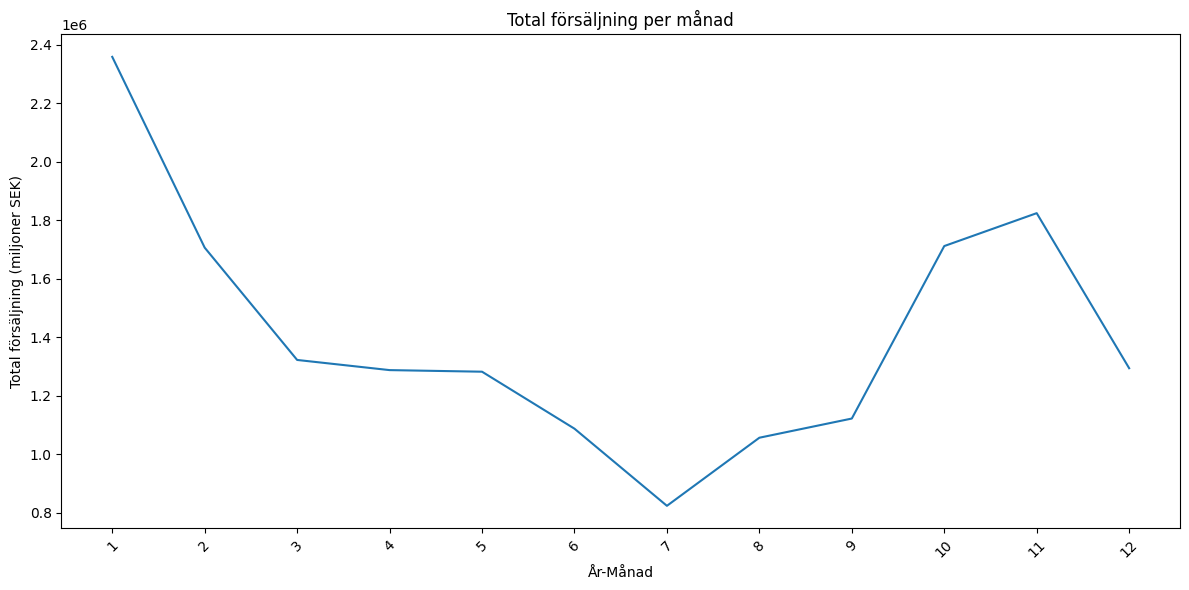

In [19]:
# 1) KPI per vecka

plt.figure(figsize=(12,6))
plt.plot(kpi_försäljning_per_månad.index.astype(str),
         kpi_försäljning_per_månad.values)

plt.title("Total försäljning per månad")
plt.xlabel("År-Månad")
plt.ylabel("Total försäljning (miljoner SEK)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Grafen visar att försäljningen är som högst under januari månad. Därefter kan man se en succesiv nedgång fram till juli, där försäljningen når sin lägsta nivå. Därefter kan man se en återhämtning resterande av året. Mönstret kan visa att det varit starkare efterfrågan i början av året. Det kan också ha varit på grund av kampanjer eller säsongsefekter.

# KPI 2 försäljning per kategori

In [13]:
kpi_försäljning_kategori = (
    df
    .groupby("kategori")["rad_intakt"]
    .sum()
    .sort_values(ascending=False)
)

kpi_försäljning_kategori

kategori
Datorer        10857219.0
Bildskärmar     3281269.0
Tillbehör       1430052.0
Lagring          696561.0
Ljud             614155.0
Name: rad_intakt, dtype: float64

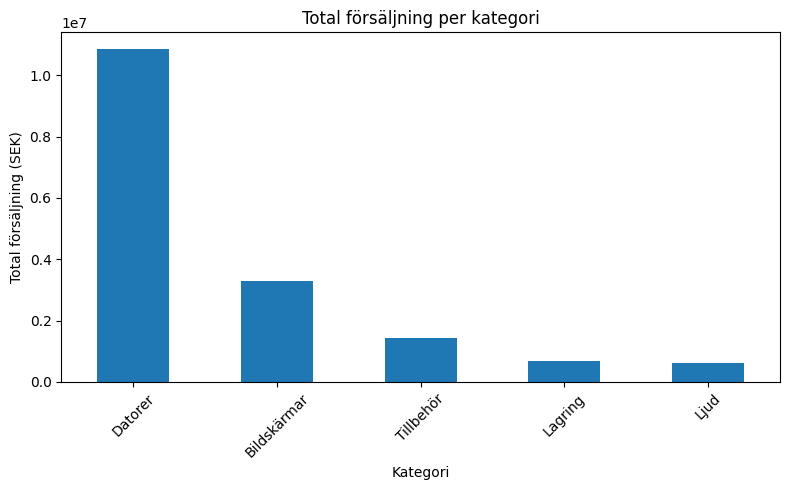

In [14]:
plt.figure(figsize=(8,5))
kpi_försäljning_kategori.plot(kind="bar")
plt.title("Total försäljning per kategori")
plt.xlabel("Kategori")
plt.ylabel("Total försäljning (SEK)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()